### Install & Import

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


import subprocess, sys

packages = [
    "PyMuPDF", "nltk", "transformers", "torch",
    "sentence-transformers", "umap-learn", "scikit-learn",
    "pandas", "numpy", "matplotlib", "seaborn",
    "scipy", "tqdm", "imbalanced-learn"
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import nltk
for pkg in ["vader_lexicon", "punkt", "punkt_tab", "stopwords", "brown"]:
    nltk.download(pkg, quiet=True)

print("✓ Dependencies ready")

### Configuration

In [4]:
import os, re, json, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

from scipy.stats import entropy as scipy_entropy, mannwhitneyu
from scipy.spatial.distance import pdist, cosine, jensenshannon
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from imblearn.over_sampling import SMOTE

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import brown, stopwords
import fitz

warnings.filterwarnings("ignore")

# ── CONFIG ────────────────────────────────────────────────────
TXT_DIR    = "/content/drive/MyDrive/data sci capstone files/processed_scripts/cleaned_scripts/sorted_by_duplicates_2/unique"
OUTPUT_DIR = "/content/drive/MyDrive/data sci capstone files/pipeline_outputs"
N_SEGMENTS = 10
EMBED_BATCH = 16
RARE_THRESHOLD = 0.0001
ERA_ORDER  = ["Pre-1980", "1980-1995 (Baseline)", "1996-2009", "2010-Present"]
COLORS     = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Config ready | Output: {OUTPUT_DIR}")

✓ Config ready | Output: /content/drive/MyDrive/data sci capstone files/pipeline_outputs


In [5]:
def parse_year(filename):
    matches = re.findall(r'(19\d{2}|20\d{2})', filename)
    for m in matches:
        y = int(m)
        if 1920 <= y <= 2026:
            return y
    return None

def era_label(year):
    if not year or pd.isna(year): return "Unknown"
    year = int(year)
    if year <= 1979: return "Pre-1980"
    if year <= 1995: return "1980-1995 (Baseline)"
    if year <= 2009: return "1996-2009"
    return "2010-Present"

print("\nLoading TXT scripts...")
txt_files = [f for f in os.listdir(TXT_DIR) if f.endswith(".txt")]
print(f"  Found {len(txt_files)} txt files")

records, skipped = [], {"no_year": 0, "too_short": 0, "read_error": 0}

for fname in tqdm(txt_files, desc="Loading"):
    year = parse_year(fname)
    if not year:
        skipped["no_year"] += 1
        continue
    try:
        with open(os.path.join(TXT_DIR, fname), "r", encoding="utf-8", errors="ignore") as f:
            text = f.read().strip()
    except:
        skipped["read_error"] += 1
        continue
    if len(text.split()) < 2000:
        skipped["too_short"] += 1
        continue
    records.append({
        "title":      fname.split("_")[0].strip(),
        "year":       year,
        "filename":   fname,
        "word_count": len(text.split()),
        "text":       text,
    })

df = pd.DataFrame(records)
df["era"]    = df["year"].apply(era_label)
df["decade"] = (df["year"] // 10) * 10
df           = df[df["era"] != "Unknown"].reset_index(drop=True)

print(f"\n✓ Loaded   : {len(df)} scripts")
print(f"  No year  : {skipped['no_year']} | Too short: {skipped['too_short']} | Error: {skipped['read_error']}")
print(f"  Years    : {int(df['year'].min())} - {int(df['year'].max())}")
print(f"\nEra distribution:")
print(df["era"].value_counts().reindex(ERA_ORDER).dropna().to_string())



Loading TXT scripts...
  Found 4225 txt files


Loading: 100%|██████████| 4225/4225 [02:51<00:00, 24.58it/s] 



✓ Loaded   : 2017 scripts
  No year  : 2075 | Too short: 133 | Error: 0
  Years    : 1920 - 2026

Era distribution:
era
Pre-1980                 130
1980-1995 (Baseline)     216
1996-2009                635
2010-Present            1036


### Preprocessing

In [6]:
def preprocess_script(text):
    lines = text.split("\n")
    clean = []
    for line in lines:
        line = line.strip()
        if not line: continue
        if re.match(r"^\d{1,3}\.?$", line): continue
        if re.match(r"^(INT|EXT|I/E)[\.\s]", line, re.IGNORECASE): continue
        if line.isupper() and len(line) < 40: continue
        if re.match(r"^\(.*\)$", line): continue
        if re.match(r"^(FADE|CUT TO|SMASH|DISSOLVE|MATCH CUT)", line, re.IGNORECASE): continue
        if re.match(r"^[-_=]{3,}$", line): continue
        if any(w in line.lower() for w in ["copyright","©","all rights reserved","wga","registered"]): continue
        clean.append(line)
    return re.sub(r"\s+", " ", " ".join(clean)).strip()

print("\nPreprocessing scripts...")
df["text_clean"] = [preprocess_script(t) for t in tqdm(df["text"], desc="Cleaning")]

orig_avg  = df["text"].apply(lambda t: len(t.split())).mean()
clean_avg = df["text_clean"].apply(lambda t: len(t.split())).mean()
removed   = (1 - clean_avg / orig_avg) * 100
print(f"✓ Noise removed: {removed:.1f}% | Avg words: {orig_avg:.0f} → {clean_avg:.0f}")

# Save clean text for reference
df[["filename","title","year","era","text_clean"]].to_csv(
    os.path.join(OUTPUT_DIR, "scripts_clean_text.csv"), index=False)
print("✓ Saved scripts_clean_text.csv")


Preprocessing scripts...


Cleaning: 100%|██████████| 2017/2017 [01:30<00:00, 22.18it/s]


✓ Noise removed: 4.7% | Avg words: 23403 → 22306
✓ Saved scripts_clean_text.csv


### Feature Engineering

In [7]:
sia = SentimentIntensityAnalyzer()

# Build Brown corpus reference
print("\nBuilding Brown corpus reference...")
brown_freq  = Counter(w.lower() for w in brown.words())
total_brown = sum(brown_freq.values())
brown_prob  = {w: c/total_brown for w, c in brown_freq.items()}

def get_sentiment_arc(text, n_segments=N_SEGMENTS, rare_only=False):
    sentences = nltk.sent_tokenize(str(text))
    if len(sentences) < n_segments:
        return None
    seg_size = len(sentences) // n_segments
    arc = []
    for i in range(n_segments):
        seg = sentences[i * seg_size:(i + 1) * seg_size]
        if rare_only:
            filtered = []
            for s in seg:
                rare_words = [w for w in s.split()
                              if w.isalpha() and
                              brown_prob.get(w.lower(), 0) < RARE_THRESHOLD]
                if rare_words:
                    filtered.append(" ".join(rare_words))
            scores = [sia.polarity_scores(s)["compound"] for s in filtered] if filtered else [0.0]
        else:
            scores = [sia.polarity_scores(s)["compound"] for s in seg]
        arc.append(np.mean(scores))
    return np.array(arc)

def transition_entropy(arc):
    diffs  = np.diff(arc)
    bins   = np.array([-1 if d < -0.05 else (1 if d > 0.05 else 0) for d in diffs])
    counts = np.array([(bins == v).sum() for v in [-1, 0, 1]], dtype=float)
    counts = counts[counts > 0]
    if len(counts) == 0: return 0.0
    probs  = counts / counts.sum()
    return float(scipy_entropy(probs, base=2))

# Compute both arcs together
print("Computing standard and rare-word sentiment arcs...")
std_arcs, rare_arcs, valid_idx = [], [], []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Arcs"):
    std_arc  = get_sentiment_arc(row["text_clean"], rare_only=False)
    rare_arc = get_sentiment_arc(row["text_clean"], rare_only=True)
    if std_arc is not None and rare_arc is not None:
        std_arcs.append(std_arc)
        rare_arcs.append(rare_arc)
        valid_idx.append(idx)

# Align df and matrices — single source of truth
df           = df.loc[valid_idx].reset_index(drop=True)
arc_matrix   = np.array(std_arcs)    # shape: (n, 10)
rare_arc_matrix = np.array(rare_arcs)  # shape: (n, 10)

# Add all arc columns to df
for i in range(N_SEGMENTS):
    df[f"arc_{i}"]      = arc_matrix[:, i]
    df[f"rare_arc_{i}"] = rare_arc_matrix[:, i]

# Entropy features
df["transition_entropy"]      = [transition_entropy(arc) for arc in arc_matrix]
df["transition_entropy_rare"] = [transition_entropy(arc) for arc in rare_arc_matrix]

print(f"\n✓ Feature engineering complete")
print(f"  Scripts     : {len(df)}")
print(f"  arc_matrix  : {arc_matrix.shape}")
print(f"  rare_matrix : {rare_arc_matrix.shape}")
print(f"  df columns  : {list(df.columns)}")

# Save
np.save(os.path.join(OUTPUT_DIR, "sentiment_arcs.npy"),      arc_matrix)
np.save(os.path.join(OUTPUT_DIR, "rare_arc_matrix.npy"), rare_arc_matrix)
df.drop(columns=["text","text_clean"]).to_csv(
    os.path.join(OUTPUT_DIR, "film_features.csv"), index=False)
print("✓ Saved sentiment_arcs.npy, rare_arc_matrix.npy, film_features.csv")


Building Brown corpus reference...
Computing standard and rare-word sentiment arcs...


Arcs: 100%|██████████| 2017/2017 [20:34<00:00,  1.63it/s]



✓ Feature engineering complete
  Scripts     : 2017
  arc_matrix  : (2017, 10)
  rare_matrix : (2017, 10)
  df columns  : ['title', 'year', 'filename', 'word_count', 'text', 'era', 'decade', 'text_clean', 'arc_0', 'rare_arc_0', 'arc_1', 'rare_arc_1', 'arc_2', 'rare_arc_2', 'arc_3', 'rare_arc_3', 'arc_4', 'rare_arc_4', 'arc_5', 'rare_arc_5', 'arc_6', 'rare_arc_6', 'arc_7', 'rare_arc_7', 'arc_8', 'rare_arc_8', 'arc_9', 'rare_arc_9', 'transition_entropy', 'transition_entropy_rare']
✓ Saved sentiment_arcs.npy, rare_arc_matrix.npy, film_features.csv


### JSD Features

In [8]:
print("\nComputing Jensen-Shannon Divergence features...")

text_col = "text_clean" if "text_clean" in df.columns else "text"
# Reload clean text if needed
if text_col not in df.columns:
    clean_df = pd.read_csv(os.path.join(OUTPUT_DIR, "scripts_clean_text.csv"))
    df = df.merge(clean_df[["filename","text_clean"]], on="filename", how="left")
    text_col = "text_clean"

vectorizer = CountVectorizer(max_features=5000, stop_words="english", min_df=2)
X_counts   = vectorizer.fit_transform(df[text_col].fillna(""))

# Era distributions
era_dists = {}
for era in ERA_ORDER:
    mask = (df["era"] == era).values
    if mask.sum() == 0: continue
    era_vec = X_counts[mask].toarray().sum(axis=0).astype(float)
    if era_vec.sum() > 0:
        era_dists[era] = era_vec / era_vec.sum()

# Era-level JSD
print("\n  JSD between eras (lower = more similar vocabulary):")
for i, era_a in enumerate(list(era_dists.keys())):
    for era_b in list(era_dists.keys())[i+1:]:
        jsd = jensenshannon(era_dists[era_a], era_dists[era_b])
        print(f"    {era_a} vs {era_b}: {jsd:.4f}")

# Per-film JSD from baseline
baseline_dist = era_dists.get("1980-1995 (Baseline)")
film_jsds, film_jsd_era = [], []

for idx in range(len(df)):
    film_vec = X_counts[idx].toarray().flatten().astype(float)
    # JSD from baseline
    if film_vec.sum() > 0 and baseline_dist is not None:
        fp = film_vec / film_vec.sum()
        film_jsds.append(float(jensenshannon(fp, baseline_dist)))
    else:
        film_jsds.append(np.nan)
    # JSD from own era mean
    era = df.iloc[idx]["era"]
    if film_vec.sum() > 0 and era in era_dists:
        fp = film_vec / film_vec.sum()
        film_jsd_era.append(float(jensenshannon(fp, era_dists[era])))
    else:
        film_jsd_era.append(np.nan)

df["jsd_from_baseline"] = film_jsds
df["jsd_from_era_mean"] = film_jsd_era

print(f"\n  Mean JSD from baseline by era:")
for era in ERA_ORDER:
    mask = df["era"] == era
    vals = df.loc[mask, "jsd_from_baseline"].dropna()
    if len(vals) > 0:
        print(f"    {era}: {vals.mean():.4f} ± {vals.std():.4f}")

pd.DataFrame([{"era_pair": f"{a} vs {b}",
               "jsd": float(jensenshannon(era_dists[a], era_dists[b]))}
              for i,a in enumerate(list(era_dists.keys()))
              for b in list(era_dists.keys())[i+1:]
              if a in era_dists and b in era_dists
             ]).to_csv(os.path.join(OUTPUT_DIR, "era_jsd_results.csv"), index=False)
print("✓ Saved era_jsd_results.csv")



Computing Jensen-Shannon Divergence features...

  JSD between eras (lower = more similar vocabulary):
    Pre-1980 vs 1980-1995 (Baseline): 0.2475
    Pre-1980 vs 1996-2009: 0.2604
    Pre-1980 vs 2010-Present: 0.2761
    1980-1995 (Baseline) vs 1996-2009: 0.1852
    1980-1995 (Baseline) vs 2010-Present: 0.2037
    1996-2009 vs 2010-Present: 0.1498

  Mean JSD from baseline by era:
    Pre-1980: 0.5090 ± 0.0482
    1980-1995 (Baseline): 0.4892 ± 0.0519
    1996-2009: 0.4920 ± 0.0504
    2010-Present: 0.5019 ± 0.0405
✓ Saved era_jsd_results.csv


### BERT Embeddings

In [9]:
from sentence_transformers import SentenceTransformer

print("\nLoading sentence-transformer (all-MiniLM-L6-v2)...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Reload clean text if dropped
if "text_clean" not in df.columns:
    clean_df   = pd.read_csv(os.path.join(OUTPUT_DIR, "scripts_clean_text.csv"))
    df         = df.merge(clean_df[["filename","text_clean"]], on="filename", how="left")

def sample_text(text, max_chars=8000):
    if len(str(text)) <= max_chars: return str(text)
    mid  = len(str(text)) // 2
    half = max_chars // 2
    return str(text)[mid-half: mid+half]

print("Generating BERT embeddings...")
texts_sampled = [sample_text(t) for t in df["text_clean"].tolist()]
embeddings    = embedder.encode(
    texts_sampled, batch_size=EMBED_BATCH,
    show_progress_bar=True, convert_to_numpy=True
)

# Verify alignment
assert len(embeddings) == len(df), f"Embedding size {len(embeddings)} != df size {len(df)}"
np.save(os.path.join(OUTPUT_DIR, "bert_embeddings.npy"), embeddings)
print(f"✓ BERT embeddings: {embeddings.shape} | aligned with df: {len(df)}")


Loading sentence-transformer (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating BERT embeddings...


Batches:   0%|          | 0/127 [00:00<?, ?it/s]

✓ BERT embeddings: (2017, 384) | aligned with df: 2017


### UMAP

In [10]:
import umap as umap_lib

print("\nRunning UMAP...")
reducer      = umap_lib.UMAP(n_components=2, random_state=42,
                              n_neighbors=10, min_dist=0.1)
embedding_2d = reducer.fit_transform(embeddings)
np.save(os.path.join(OUTPUT_DIR, "umap_2d.npy"), embedding_2d)
era_color_map = dict(zip(ERA_ORDER, COLORS))
print(f"✓ UMAP complete: {embedding_2d.shape}")



Running UMAP...
✓ UMAP complete: (2017, 2)


### Exploratory Data Analysis


Generating EDA visualizations...


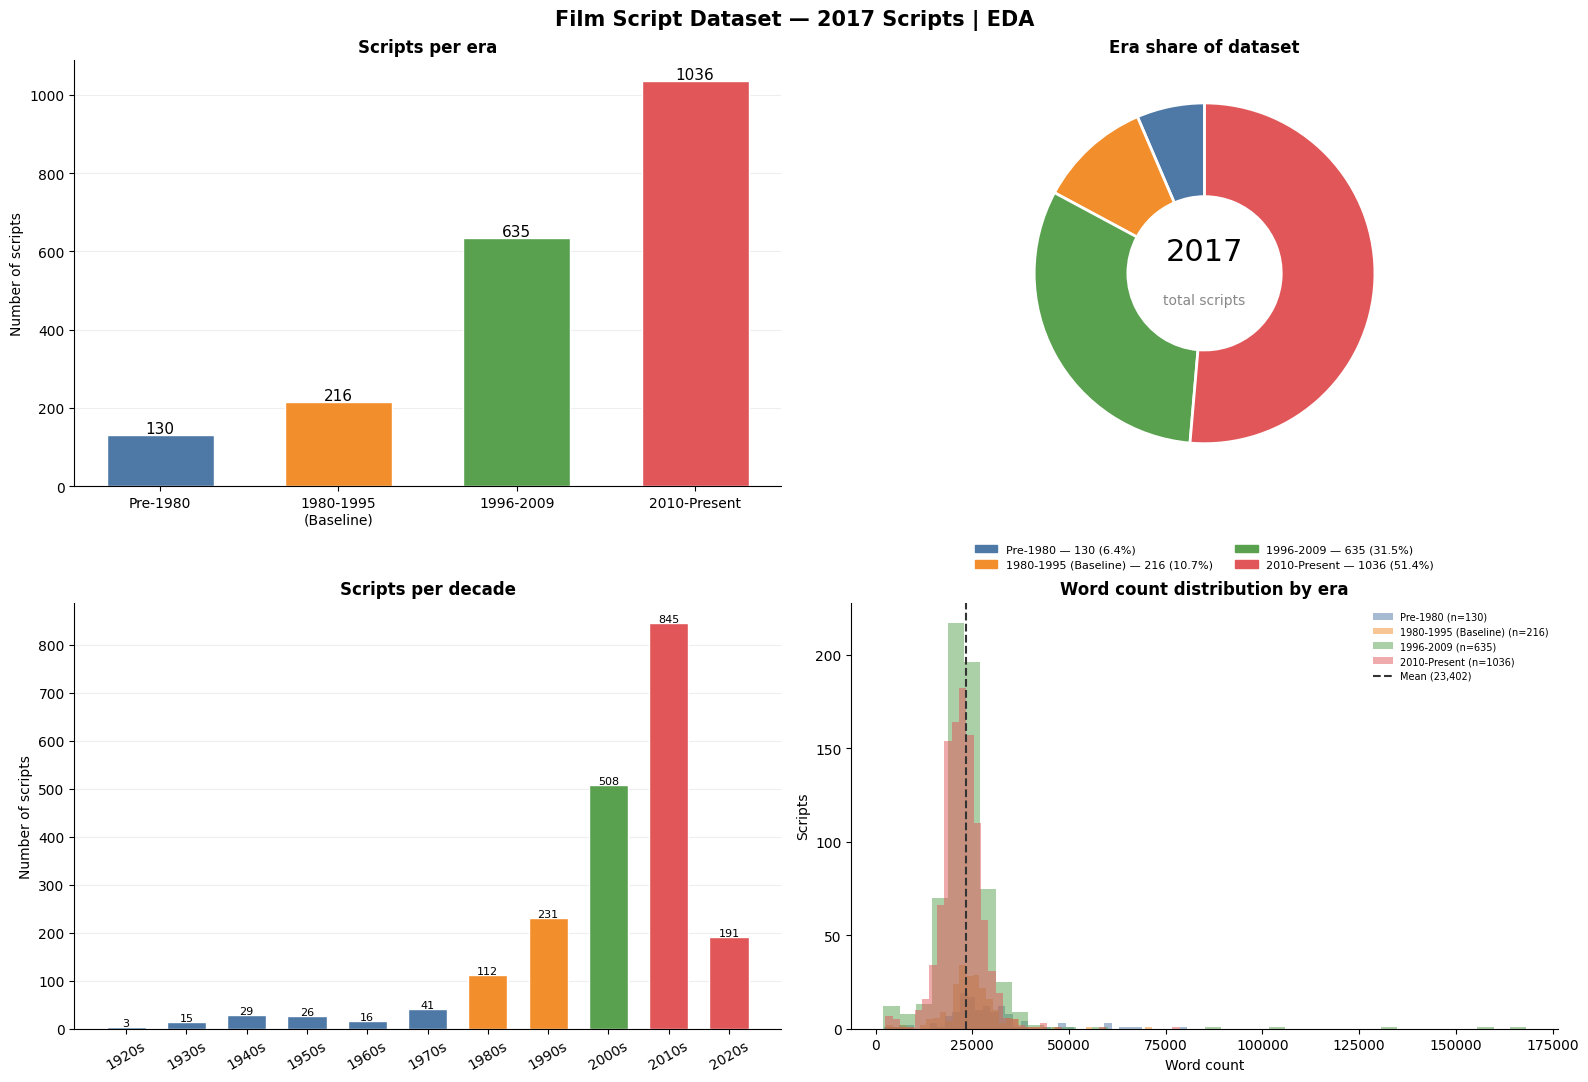

✓ Saved eda_dashboard.png


In [11]:
print("\nGenerating EDA visualizations...")

era_counts    = df["era"].value_counts().reindex(ERA_ORDER).fillna(0)
decade_counts = df.groupby("decade").size()
decades       = sorted(decade_counts.index)
total         = len(df)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f"Film Script Dataset — {total} Scripts | EDA",
             fontsize=15, fontweight="bold")

# Era bar
ax = axes[0,0]
bars = ax.bar(range(len(ERA_ORDER)), era_counts.values,
              color=COLORS, edgecolor="white", width=0.6)
for bar, val in zip(bars, era_counts.values):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(int(val)), ha="center", fontsize=11, fontweight="500")
ax.set_xticks(range(len(ERA_ORDER)))
ax.set_xticklabels(["Pre-1980","1980-1995\n(Baseline)","1996-2009","2010-Present"], fontsize=10)
ax.set_title("Scripts per era", fontweight="bold")
ax.set_ylabel("Number of scripts")
ax.yaxis.grid(True, color="#eeeeee", zorder=0); ax.set_axisbelow(True)
sns.despine(ax=ax)

# Donut
ax = axes[0,1]
ax.pie(era_counts.values, colors=COLORS, startangle=90,
       wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2))
ax.text(0, 0.08, str(total), ha="center", fontsize=22, fontweight="500")
ax.text(0, -0.18, "total scripts", ha="center", fontsize=10, color="#888888")
legend_p = [mpatches.Patch(color=c, label=f"{e} — {int(v)} ({v/total*100:.1f}%)")
            for c,e,v in zip(COLORS, ERA_ORDER, era_counts.values)]
ax.legend(handles=legend_p, loc="lower center", bbox_to_anchor=(0.5,-0.22),
          fontsize=8, frameon=False, ncol=2)
ax.set_title("Era share of dataset", fontweight="bold")

# Decade bar
ax = axes[1,0]
def dec_color(d):
    if d < 1980: return "#4e79a7"
    if d < 1996: return "#f28e2b"
    if d < 2010: return "#59a14f"
    return "#e15759"
bars3 = ax.bar([f"{d}s" for d in decades],
               [decade_counts[d] for d in decades],
               color=[dec_color(d) for d in decades],
               edgecolor="white", width=0.65)
for bar, val in zip(bars3, [decade_counts[d] for d in decades]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            str(int(val)), ha="center", fontsize=8)
ax.set_title("Scripts per decade", fontweight="bold")
ax.set_ylabel("Number of scripts")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.grid(True, color="#eeeeee", zorder=0); ax.set_axisbelow(True)
sns.despine(ax=ax)

# Word count
ax = axes[1,1]
for era, color in zip(ERA_ORDER, COLORS):
    sub = df[df["era"]==era]["word_count"]
    if len(sub) > 0:
        ax.hist(sub, bins=40, alpha=0.5, color=color, label=f"{era} (n={len(sub)})")
ax.axvline(df["word_count"].mean(), color="#333333", ls="--", lw=1.5,
           label=f"Mean ({int(df['word_count'].mean()):,})")
ax.set_title("Word count distribution by era", fontweight="bold")
ax.set_xlabel("Word count"); ax.set_ylabel("Scripts")
ax.legend(fontsize=7, frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_dashboard.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved eda_dashboard.png")

### Baseline Model — BERT + KMeans


BASELINE MODEL: BERT + KMeans

  Silhouette Score    : 0.0099
  Adjusted Rand Index : 0.0073
  (ARI: 0=random, 1=perfect era alignment, negative=worse than random)

  Cluster x Era:
Era      1980-1995 (Baseline)  1996-2009  2010-Present  Pre-1980
Cluster                                                         
0                          45        157           335        31
1                          60        179           272        27
2                          51        165           218        31
3                          60        134           211        41


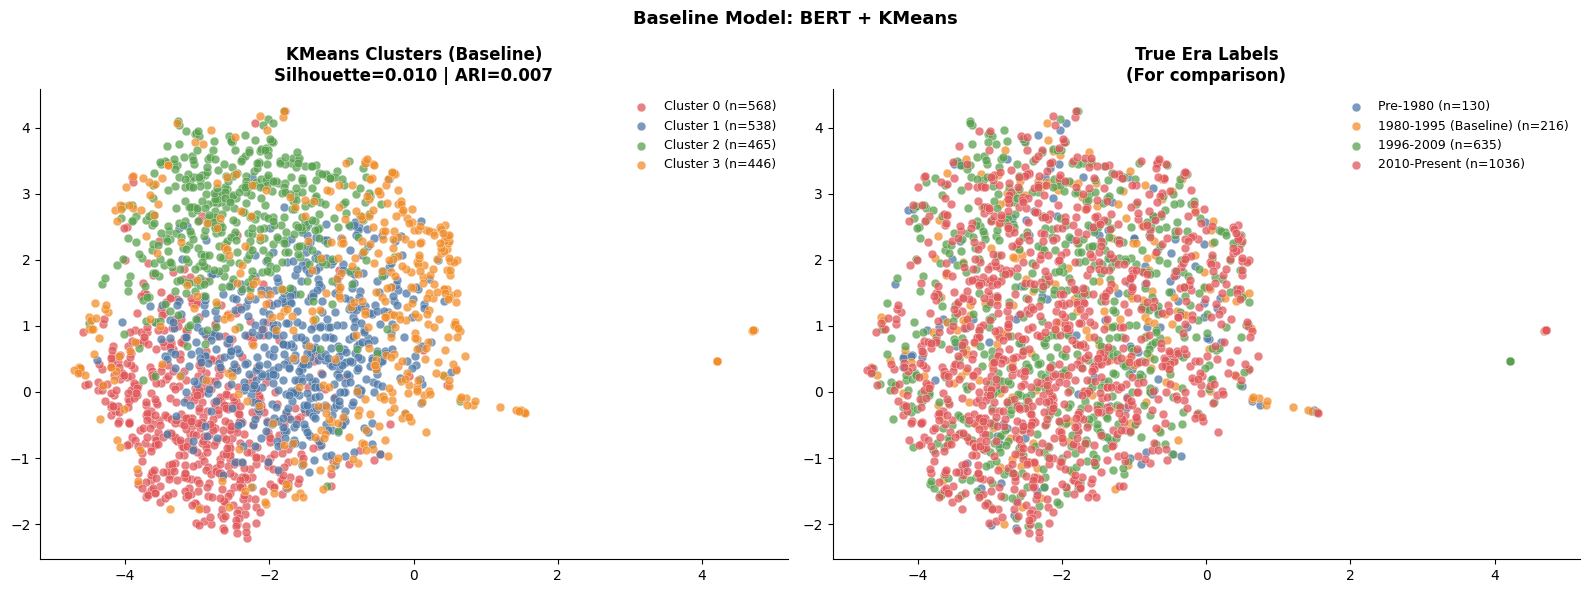

✓ Saved baseline_kmeans.png


In [12]:
print("\n" + "="*60)
print("BASELINE MODEL: BERT + KMeans")
print("="*60)

kmeans         = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"]  = kmeans.fit_predict(embeddings)

sil_score = silhouette_score(embeddings, df["cluster"])
le_era    = LabelEncoder()
era_int   = le_era.fit_transform(df["era"].values)
ari_score = adjusted_rand_score(era_int, df["cluster"])

print(f"\n  Silhouette Score    : {sil_score:.4f}")
print(f"  Adjusted Rand Index : {ari_score:.4f}")
print(f"  (ARI: 0=random, 1=perfect era alignment, negative=worse than random)")

crosstab = pd.crosstab(df["cluster"], df["era"],
                        rownames=["Cluster"], colnames=["Era"])
print(f"\n  Cluster x Era:")
print(crosstab.to_string())
crosstab.to_csv(os.path.join(OUTPUT_DIR, "baseline_cluster_crosstab.csv"))

# Side-by-side UMAP plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cluster_colors = ["#e15759","#4e79a7","#59a14f","#f28e2b"]
for c in range(4):
    mask = df["cluster"] == c
    pts  = embedding_2d[mask.values]
    axes[0].scatter(pts[:,0], pts[:,1], label=f"Cluster {c} (n={mask.sum()})",
                    color=cluster_colors[c], alpha=0.75, s=40, edgecolors="white", lw=0.3)
axes[0].set_title(f"KMeans Clusters (Baseline)\nSilhouette={sil_score:.3f} | ARI={ari_score:.3f}",
                   fontweight="bold")
axes[0].legend(fontsize=9, frameon=False)
sns.despine(ax=axes[0])

for era in ERA_ORDER:
    mask = df["era"] == era
    if mask.sum() == 0: continue
    pts = embedding_2d[mask.values]
    axes[1].scatter(pts[:,0], pts[:,1], label=f"{era} (n={mask.sum()})",
                    color=era_color_map[era], alpha=0.75, s=40, edgecolors="white", lw=0.3)
axes[1].set_title("True Era Labels\n(For comparison)", fontweight="bold")
axes[1].legend(fontsize=9, frameon=False)
sns.despine(ax=axes[1])

plt.suptitle("Baseline Model: BERT + KMeans", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_kmeans.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved baseline_kmeans.png")

with open(os.path.join(OUTPUT_DIR, "baseline_results.json"), "w") as f:
    json.dump({"silhouette": float(sil_score), "ari": float(ari_score)}, f, indent=2)

### Improved Model - Random Forest


IMPROVED MODEL: Random Forest Era Classifier

  Scripts: 1252
era
2010-Present            1036
1980-1995 (Baseline)     216

  Features: 24

  After SMOTE: Counter({np.int64(1): 828, np.int64(0): 828})

── Random Forest ──
                      precision    recall  f1-score   support

1980-1995 (Baseline)       0.29      0.23      0.26        43
        2010-Present       0.85      0.88      0.87       208

            accuracy                           0.77       251
           macro avg       0.57      0.56      0.56       251
        weighted avg       0.75      0.77      0.76       251

  CV F1: 0.757 ± 0.007

── Logistic Regression ──
                      precision    recall  f1-score   support

1980-1995 (Baseline)       0.20      0.51      0.28        43
        2010-Present       0.85      0.57      0.68       208

            accuracy                           0.56       251
           macro avg       0.52      0.54      0.48       251
        weighted avg       0.74      0.

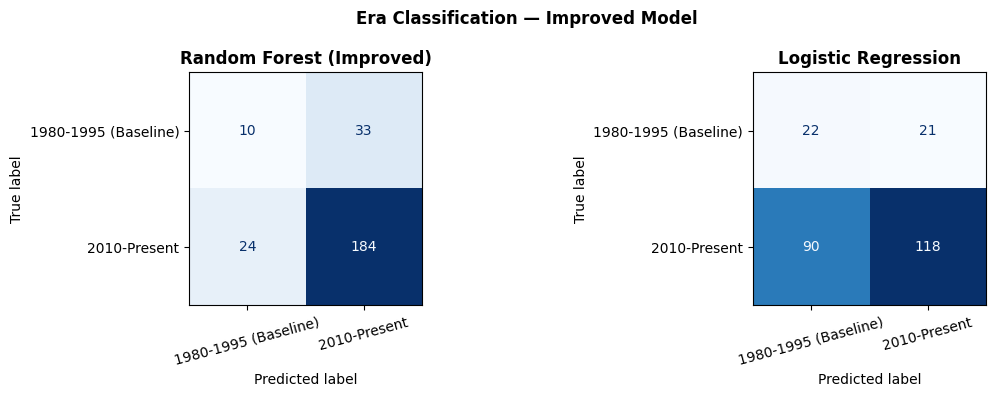

✓ Saved improved_confusion_matrix.png


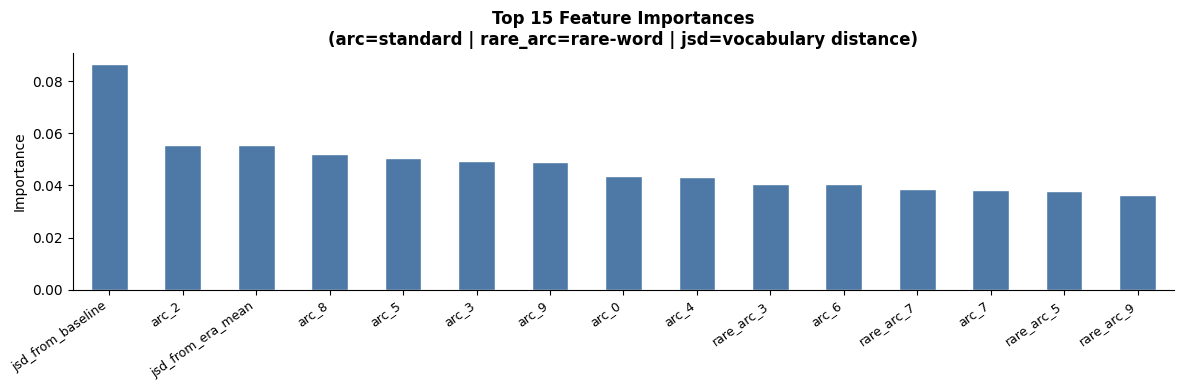

✓ Saved feature_importance.png


In [13]:
print("\n" + "="*60)
print("IMPROVED MODEL: Random Forest Era Classifier")
print("="*60)

df_model = df[df["era"].isin(["1980-1995 (Baseline)", "2010-Present"])].copy()
print(f"\n  Scripts: {len(df_model)}")
print(df_model["era"].value_counts().to_string())

# Full feature set — all computed from df so always aligned
feature_cols = (
    [f"arc_{i}" for i in range(N_SEGMENTS)] +
    [f"rare_arc_{i}" for i in range(N_SEGMENTS)] +
    ["transition_entropy", "transition_entropy_rare",
     "jsd_from_baseline", "jsd_from_era_mean"]
)
feature_cols = [c for c in feature_cols if c in df_model.columns]
print(f"\n  Features: {len(feature_cols)}")

X  = df_model[feature_cols].fillna(0).values
le = LabelEncoder()
y  = le.fit_transform(df_model["era"].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
print(f"\n  After SMOTE: {Counter(y_train_bal)}")

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train_bal, y_train_bal)
y_pred = rf.predict(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test)

n_splits = min(5, len(df_model)//4)
cv_rf = cross_val_score(rf, X, y, cv=n_splits, scoring="f1_weighted")
cv_lr = cross_val_score(lr, X, y, cv=n_splits, scoring="f1_weighted")

print(f"\n── Random Forest ──")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
print(f"  CV F1: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")

print(f"\n── Logistic Regression ──")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_, zero_division=0))
print(f"  CV F1: {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yp, title in zip(axes, [y_pred, y_pred_lr],
                           ["Random Forest (Improved)", "Logistic Regression"]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, yp),
                           display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Era Classification — Improved Model", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "improved_confusion_matrix.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved improved_confusion_matrix.png")

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax  = plt.subplots(figsize=(12, 4))
feat_imp.head(15).plot(kind="bar", ax=ax, color="#4e79a7", edgecolor="white")
ax.set_title("Top 15 Feature Importances\n(arc=standard | rare_arc=rare-word | jsd=vocabulary distance)",
             fontweight="bold")
ax.set_ylabel("Importance")
plt.xticks(rotation=35, ha="right", fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved feature_importance.png")

with open(os.path.join(OUTPUT_DIR, "improved_results.json"), "w") as f:
    json.dump({"rf_cv_f1": float(cv_rf.mean()), "rf_cv_f1_std": float(cv_rf.std()),
               "lr_cv_f1": float(cv_lr.mean())}, f, indent=2)



### Rolling Window Clustering

ADVANCED CLUSTERING: Rolling Window (5-year windows)

  Windows: 10 | Size: 5 yrs | Min: 15 scripts


Windows: 100%|██████████| 10/10 [00:00<00:00, 22.47it/s]



  Results:
   window  n_scripts  silhouette  mean_pairwise_dist
1975-1979         30      0.1868              0.8998
1980-1984         38      0.1850              0.9151
1985-1989         74      0.1322                 NaN
1990-1994         80      0.1744              0.9484
1995-1999        151      0.2041              0.9785
2000-2004        121      0.1922              0.9560
2005-2009        387      0.1967              0.9536
2010-2014        529      0.1869              0.9387
2015-2019        316      0.1993              0.9233
2020-2024        146      0.1701              0.8574


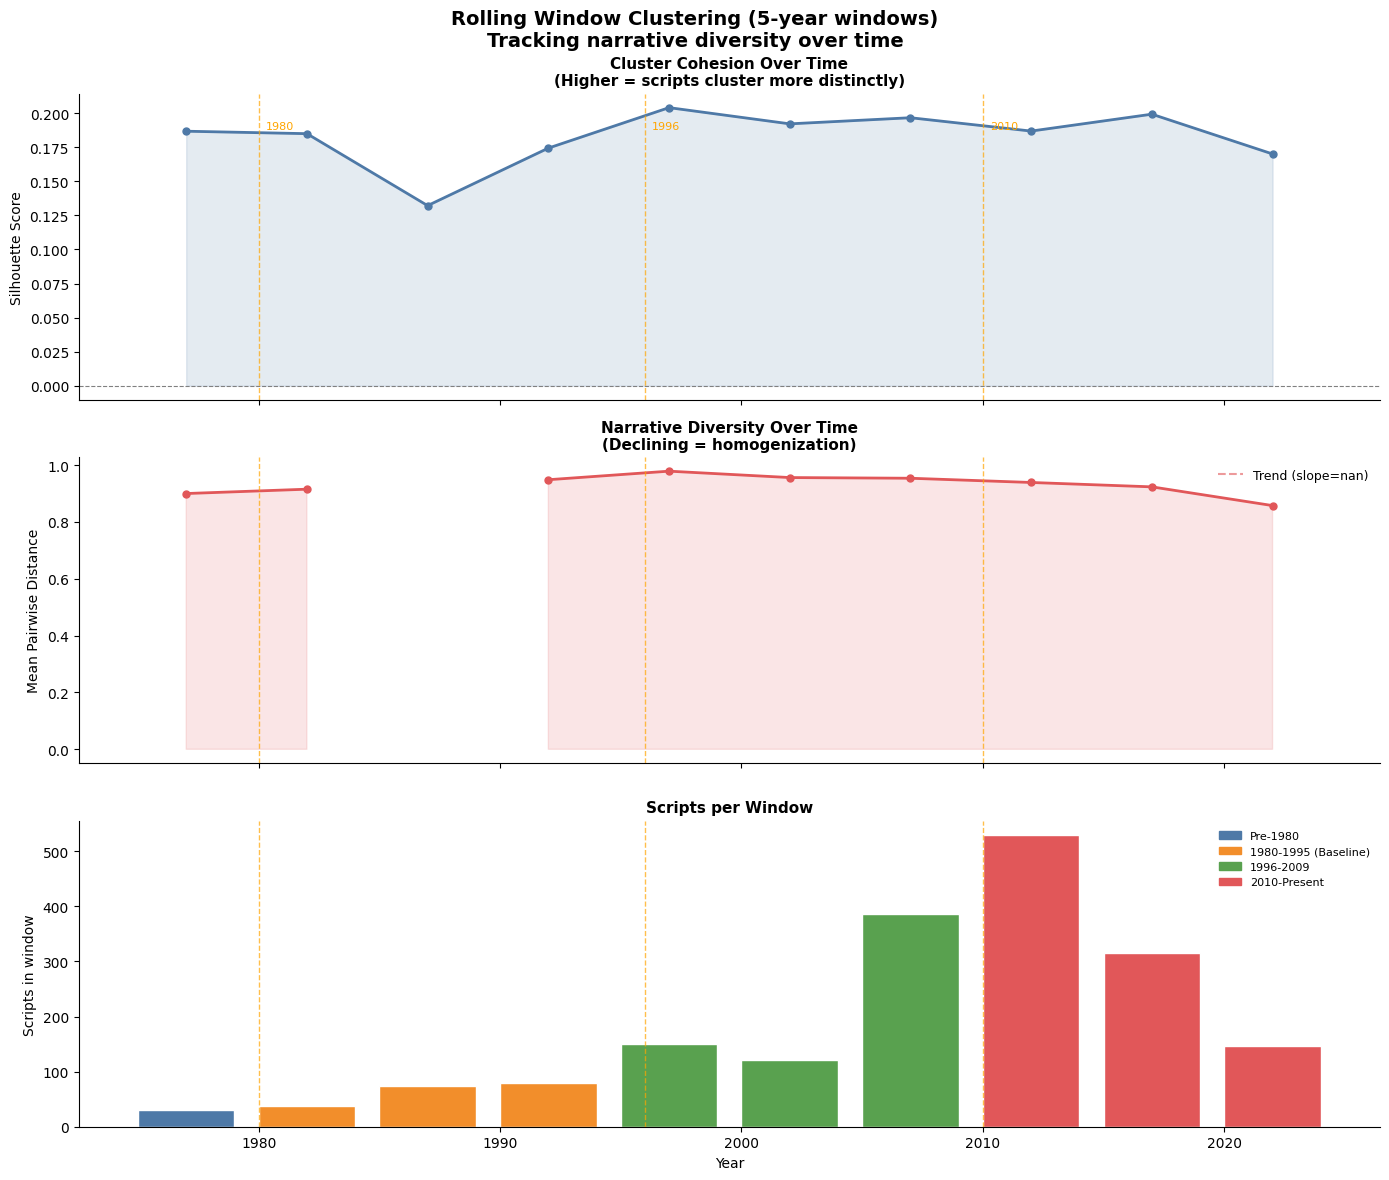

✓ Saved rolling_window_trends.png


In [14]:
print("ADVANCED CLUSTERING: Rolling Window (5-year windows)")
print("="*60)

WINDOW_SIZE = 5
MIN_SCRIPTS = 15
feature_matrix = normalize(np.hstack([arc_matrix, rare_arc_matrix]))

df_year  = df[df["year"].between(1975, 2026)].copy()
year_min = int(df_year["year"].min())
year_max = int(df_year["year"].max())
windows  = [(s, s+WINDOW_SIZE-1) for s in range(year_min, year_max-WINDOW_SIZE+2, WINDOW_SIZE)
            if df_year["year"].between(s, s+WINDOW_SIZE-1).sum() >= MIN_SCRIPTS]

print(f"\n  Windows: {len(windows)} | Size: {WINDOW_SIZE} yrs | Min: {MIN_SCRIPTS} scripts")

window_results = []
for start, end in tqdm(windows, desc="Windows"):
    mask    = df["year"].between(start, end).values
    pos     = np.where(mask)[0]
    if len(pos) < MIN_SCRIPTS: continue

    feat_sub = feature_matrix[pos]
    k        = min(3, len(pos)//5)
    if k < 2: continue

    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(feat_sub)
    sil = silhouette_score(feat_sub, lbl) if len(np.unique(lbl)) > 1 else 0.0
    pw  = pdist(arc_matrix[pos], metric="cosine")

    window_results.append({
        "window": f"{start}-{end}", "start": start, "end": end,
        "midpoint": (start+end)/2, "n_scripts": len(pos),
        "silhouette": round(sil, 4),
        "mean_pairwise_dist": round(float(np.mean(pw)), 4),
        "std_pairwise_dist":  round(float(np.std(pw)), 4),
    })

window_df = pd.DataFrame(window_results)
window_df.to_csv(os.path.join(OUTPUT_DIR, "rolling_window_clustering.csv"), index=False)
print(f"\n  Results:")
print(window_df[["window","n_scripts","silhouette","mean_pairwise_dist"]].to_string(index=False))

# Plot rolling window trends
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Rolling Window Clustering (5-year windows)\nTracking narrative diversity over time",
             fontsize=14, fontweight="bold")
mid = window_df["midpoint"].values

ax = axes[0]
ax.plot(mid, window_df["silhouette"], color="#4e79a7", lw=2, marker="o", ms=5)
ax.fill_between(mid, window_df["silhouette"], alpha=0.15, color="#4e79a7")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_ylabel("Silhouette Score")
ax.set_title("Cluster Cohesion Over Time\n(Higher = scripts cluster more distinctly)",
             fontweight="bold", fontsize=11)
for yr, lbl in [(1980,"1980"),(1996,"1996"),(2010,"2010")]:
    ax.axvline(yr, color="orange", ls="--", lw=1, alpha=0.7)
    ax.text(yr+0.3, ax.get_ylim()[1]*0.88, lbl, fontsize=8, color="orange")
sns.despine(ax=ax)

ax = axes[1]
ax.plot(mid, window_df["mean_pairwise_dist"], color="#e15759", lw=2, marker="o", ms=5)
ax.fill_between(mid, window_df["mean_pairwise_dist"], alpha=0.15, color="#e15759")
if len(mid) > 3:
    z = np.polyfit(mid, window_df["mean_pairwise_dist"], 1)
    ax.plot(mid, np.poly1d(z)(mid), color="#e15759", ls="--", lw=1.5, alpha=0.6,
            label=f"Trend (slope={z[0]:.5f})")
    ax.legend(fontsize=9, frameon=False)
ax.set_ylabel("Mean Pairwise Distance")
ax.set_title("Narrative Diversity Over Time\n(Declining = homogenization)",
             fontweight="bold", fontsize=11)
for yr in [1980,1996,2010]:
    ax.axvline(yr, color="orange", ls="--", lw=1, alpha=0.7)
sns.despine(ax=ax)

ax = axes[2]
era_colors_win = ["#4e79a7" if r<1980 else "#f28e2b" if r<1996 else "#59a14f" if r<2010
                  else "#e15759" for r in window_df["midpoint"]]
ax.bar(mid, window_df["n_scripts"], width=WINDOW_SIZE*0.8,
       color=era_colors_win, edgecolor="white")
ax.set_ylabel("Scripts in window"); ax.set_xlabel("Year")
ax.set_title("Scripts per Window", fontweight="bold", fontsize=11)
ax.legend(handles=[mpatches.Patch(color=c, label=e) for c,e in zip(COLORS,ERA_ORDER)],
          fontsize=8, frameon=False)
for yr in [1980,1996,2010]:
    ax.axvline(yr, color="orange", ls="--", lw=1, alpha=0.7)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rolling_window_trends.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved rolling_window_trends.png")

### Pairwise Distance Analysis

PAIRWISE DISTANCE ANALYSIS BY ERA

  Pre-1980 (n=130):
    Arc  — mean=0.8542 std=0.4084
    BERT — mean=0.7140 std=0.0988

  1980-1995 (Baseline) (n=216):
    Arc  — mean=nan std=nan
    BERT — mean=0.7233 std=0.0949

  1996-2009 (n=635):
    Arc  — mean=0.9606 std=0.4584
    BERT — mean=0.7150 std=0.1039

  2010-Present (n=1036):
    Arc  — mean=0.9211 std=0.4553
    BERT — mean=0.7148 std=0.0973

  Mann-Whitney U (arc, Modern < Baseline): p=nan
  Distance reduction: +nan%
  ✗ Not significant


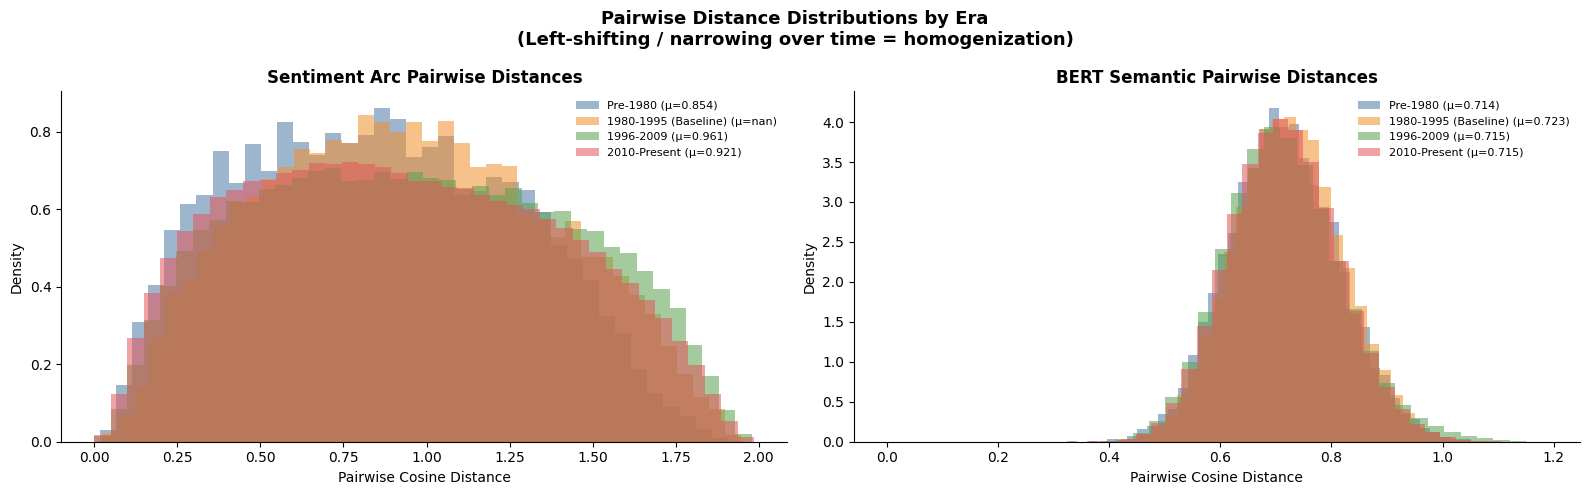

✓ Saved pairwise_distances.png


In [15]:
print("PAIRWISE DISTANCE ANALYSIS BY ERA")
print("="*60)

era_dist_arc  = {}
era_dist_bert = {}

for era in ERA_ORDER:
    mask = (df["era"] == era).values
    if mask.sum() < 2: continue
    pw_arc  = pdist(arc_matrix[mask],  metric="cosine")
    pw_bert = pdist(embeddings[mask],  metric="cosine")
    era_dist_arc[era]  = pw_arc
    era_dist_bert[era] = pw_bert
    print(f"\n  {era} (n={mask.sum()}):")
    print(f"    Arc  — mean={pw_arc.mean():.4f} std={pw_arc.std():.4f}")
    print(f"    BERT — mean={pw_bert.mean():.4f} std={pw_bert.std():.4f}")

if "1980-1995 (Baseline)" in era_dist_arc and "2010-Present" in era_dist_arc:
    _, p = mannwhitneyu(era_dist_arc["2010-Present"],
                         era_dist_arc["1980-1995 (Baseline)"],
                         alternative="less")
    pct = (era_dist_arc["1980-1995 (Baseline)"].mean() -
           era_dist_arc["2010-Present"].mean()) / \
           era_dist_arc["1980-1995 (Baseline)"].mean() * 100
    print(f"\n  Mann-Whitney U (arc, Modern < Baseline): p={p:.4f}")
    print(f"  Distance reduction: {pct:+.1f}%")
    print(f"  {'✓ SIGNIFICANT convergence' if p < 0.05 else '✗ Not significant'}")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Pairwise Distance Distributions by Era\n"
             "(Left-shifting / narrowing over time = homogenization)",
             fontsize=13, fontweight="bold")
for ax, dist_dict, title in zip(axes,
    [era_dist_arc, era_dist_bert],
    ["Sentiment Arc Pairwise Distances", "BERT Semantic Pairwise Distances"]):
    for era, color in zip(ERA_ORDER, COLORS):
        if era not in dist_dict: continue
        ax.hist(dist_dict[era], bins=40, alpha=0.55, color=color,
                label=f"{era} (μ={dist_dict[era].mean():.3f})", density=True)
    ax.set_xlabel("Pairwise Cosine Distance"); ax.set_ylabel("Density")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pairwise_distances.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved pairwise_distances.png")



CLUSTER INTERPRETABILITY

  Silhouette (arc+rare_arc): 0.1776

  Cluster 0 (691 scripts):
    Dominant era : 2010-Present
    Era split    : {'2010-Present': 338, '1996-2009': 247, '1980-1995 (Baseline)': 74, 'Pre-1980': 32}
    Arc shape    : start=-0.012 mid=-0.027 end=-0.033
    Top words    : looks, like, just, cont, don, door, know, eyes
    Rep scripts  :
      • Shadow Company (1988) [1980-1995 (Baseline)]
      • Dracula Untold (2006) [1996-2009]
      • Phobia (2009) [1996-2009]
      • The Long Kiss Goodnight (1995) [1980-1995 (Baseline)]
      • Abattoir (2012) [2010-Present]

  Cluster 1 (660 scripts):
    Dominant era : 2010-Present
    Era split    : {'2010-Present': 363, '1996-2009': 194, '1980-1995 (Baseline)': 56, 'Pre-1980': 47}
    Arc shape    : start=0.059 mid=0.056 end=0.053
    Top words    : just, like, don, cont, looks, know, ll, right
    Rep scripts  :
      • The Kindergarten Teacher (2017) [2010-Present]
      • Eyes-of-Tammy-Faye-The-(2021).txt (2021) [201

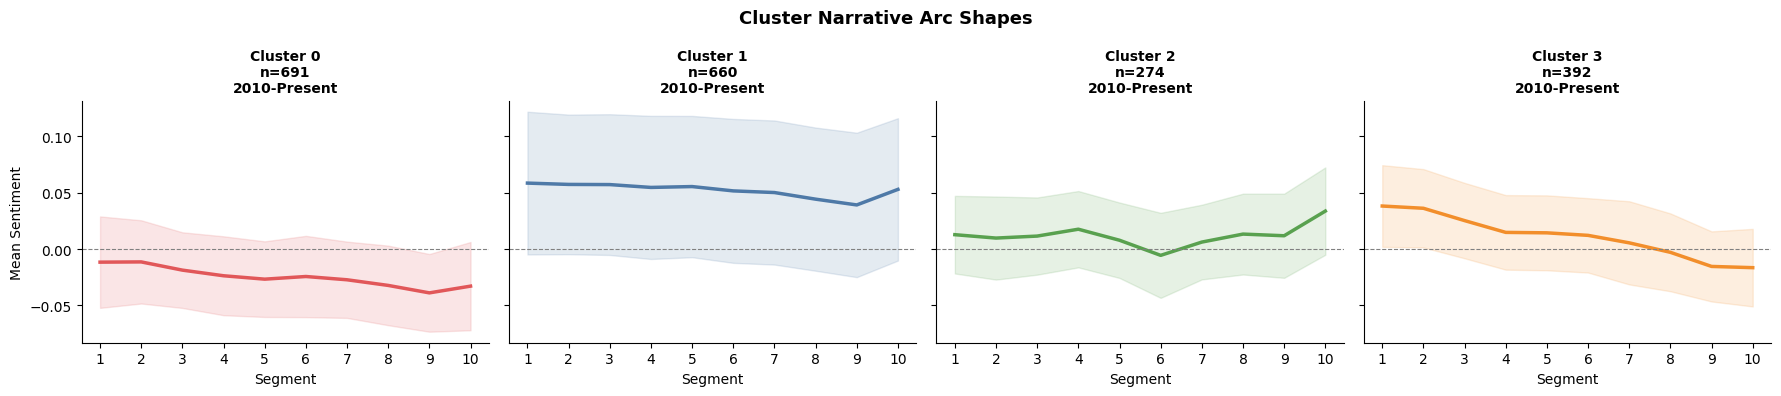

✓ Saved cluster_arc_shapes.png


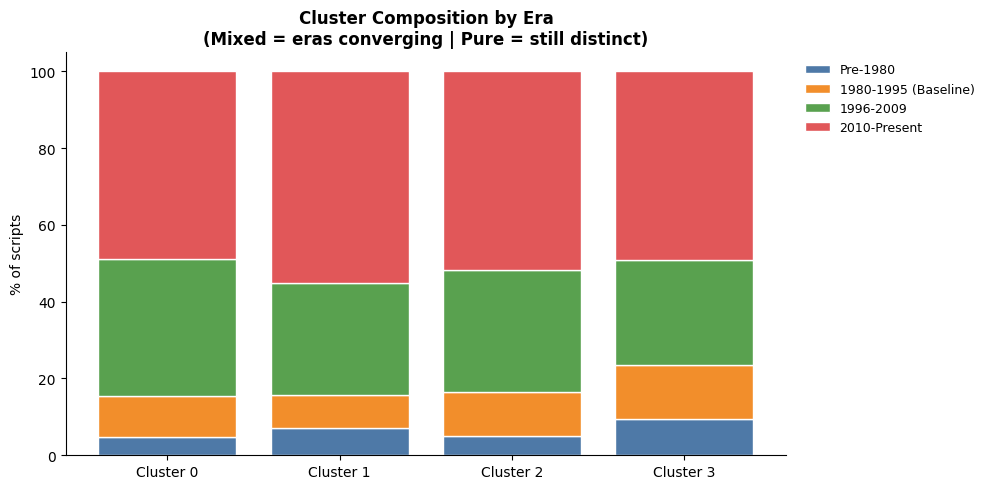

✓ Saved cluster_composition.png


In [16]:
print("CLUSTER INTERPRETABILITY")
print("="*60)

feat_mat = normalize(np.hstack([arc_matrix, rare_arc_matrix]))
km4      = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster_label"] = km4.fit_predict(feat_mat)
sil4 = silhouette_score(feat_mat, df["cluster_label"])
print(f"\n  Silhouette (arc+rare_arc): {sil4:.4f}")

# Top TF-IDF words per cluster
if "text_clean" not in df.columns:
    clean_df = pd.read_csv(os.path.join(OUTPUT_DIR, "scripts_clean_text.csv"))
    df = df.merge(clean_df[["filename","text_clean"]], on="filename", how="left")

tfidf = TfidfVectorizer(max_features=3000, stop_words="english", min_df=2)
tfidf_mat = tfidf.fit_transform(df["text_clean"].fillna(""))
vocab     = tfidf.get_feature_names_out()

profiles = []
for c in range(4):
    mask     = (df["cluster_label"] == c).values
    centroid = km4.cluster_centers_[c]
    dists    = np.linalg.norm(feat_mat[mask] - centroid, axis=1)
    closest  = np.where(mask)[0][np.argsort(dists)[:5]]
    era_dist = df[mask]["era"].value_counts()
    dominant = era_dist.index[0] if len(era_dist) > 0 else "?"
    avg_arc  = arc_matrix[mask].mean(axis=0)
    top_words = vocab[tfidf_mat[mask].toarray().mean(axis=0).argsort()[-8:][::-1]]

    print(f"\n  Cluster {c} ({mask.sum()} scripts):")
    print(f"    Dominant era : {dominant}")
    print(f"    Era split    : {era_dist.to_dict()}")
    print(f"    Arc shape    : start={avg_arc[0]:.3f} mid={avg_arc[4]:.3f} end={avg_arc[-1]:.3f}")
    print(f"    Top words    : {', '.join(top_words)}")
    print(f"    Rep scripts  :")
    for idx in closest:
        row = df.iloc[idx]
        print(f"      • {row.get('title','?')} ({int(row['year'])}) [{row['era']}]")

    profiles.append({"cluster": c, "n": int(mask.sum()), "dominant_era": dominant,
                     "top_words": ", ".join(top_words)})

pd.DataFrame(profiles).to_csv(os.path.join(OUTPUT_DIR, "cluster_profiles.csv"), index=False)

# Arc shape plot
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig.suptitle("Cluster Narrative Arc Shapes", fontsize=13, fontweight="bold")
clust_cols = ["#e15759","#4e79a7","#59a14f","#f28e2b"]
x = np.arange(1, N_SEGMENTS+1)
for c, ax in enumerate(axes):
    mask    = (df["cluster_label"] == c).values
    avg_arc = arc_matrix[mask].mean(axis=0)
    std_arc = arc_matrix[mask].std(axis=0)
    dominant = df[mask]["era"].value_counts().index[0] if mask.sum() > 0 else "?"
    ax.plot(x, avg_arc, color=clust_cols[c], lw=2.5)
    ax.fill_between(x, avg_arc-std_arc, avg_arc+std_arc, alpha=0.15, color=clust_cols[c])
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_title(f"Cluster {c}\nn={mask.sum()}\n{dominant[:12]}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Segment"); ax.set_xticks(x)
    if c == 0: ax.set_ylabel("Mean Sentiment")
    sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_arc_shapes.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved cluster_arc_shapes.png")

# Cluster composition
fig, ax = plt.subplots(figsize=(10, 5))
crosstab4 = pd.crosstab(df["cluster_label"], df["era"])
crosstab4_pct = crosstab4.div(crosstab4.sum(axis=1), axis=0) * 100
bottom = np.zeros(4)
for era, color in zip(ERA_ORDER, COLORS):
    if era not in crosstab4_pct.columns: continue
    vals = [crosstab4_pct.loc[c,era] if c in crosstab4_pct.index else 0 for c in range(4)]
    ax.bar(range(4), vals, bottom=bottom, color=color, label=era, edgecolor="white")
    bottom += np.array(vals)
ax.set_xticks(range(4))
ax.set_xticklabels([f"Cluster {c}" for c in range(4)])
ax.set_ylabel("% of scripts")
ax.set_title("Cluster Composition by Era\n(Mixed = eras converging | Pure = still distinct)",
             fontweight="bold")
ax.legend(fontsize=9, frameon=False, bbox_to_anchor=(1.01,1))
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_composition.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved cluster_composition.png")

### Statistical Test

In [17]:
print("\n" + "="*60)
print("STATISTICAL EVALUATION")
print("="*60)

sim_matrix = cosine_similarity(arc_matrix)
def era_sims(era_name):
    mask = (df["era"] == era_name).values
    if mask.sum() < 2: return np.array([])
    sub = sim_matrix[np.ix_(mask, mask)]
    np.fill_diagonal(sub, np.nan)
    return sub[~np.isnan(sub)].flatten()

baseline_sims = era_sims("1980-1995 (Baseline)")
modern_sims   = era_sims("2010-Present")

p_val = pct_change = None
if len(baseline_sims) > 0 and len(modern_sims) > 0:
    _, p_val   = mannwhitneyu(modern_sims, baseline_sims, alternative="greater")
    pct_change = (np.mean(modern_sims)-np.mean(baseline_sims))/np.mean(baseline_sims)*100
    print(f"\n  Arc Similarity — Baseline mean : {np.mean(baseline_sims):.4f}")
    print(f"  Arc Similarity — Modern mean   : {np.mean(modern_sims):.4f}")
    print(f"  Change                         : {pct_change:+.1f}%")
    print(f"  Mann-Whitney p-value           : {p_val:.4f}")
    print(f"  Charter threshold (>=20%)      : {'✓ MET' if pct_change >= 20 else '✗ NOT MET'}")
    print(f"  Statistical significance       : {'✓ p<0.05' if p_val < 0.05 else '✗ p>=0.05'}")




STATISTICAL EVALUATION

  Arc Similarity — Baseline mean : 0.0549
  Arc Similarity — Modern mean   : 0.0789
  Change                         : +43.7%
  Mann-Whitney p-value           : 0.0000
  Charter threshold (>=20%)      : ✓ MET
  Statistical significance       : ✓ p<0.05


### Summary

In [18]:

print("\n" + "="*60)
print("PIPELINE COMPLETE — FULL SUMMARY")
print("="*60)
print(f"\n  Dataset          : {len(df)} scripts | {int(df['year'].min())}-{int(df['year'].max())}")
print(f"  Preprocessing    : {removed:.1f}% noise removed")
print(f"  Features         : {len(feature_cols)} total (arc + rare_arc + entropy + JSD)")
print(f"\n  BASELINE (BERT+KMeans):")
print(f"    Silhouette     : {sil_score:.4f}")
print(f"    ARI            : {ari_score:.4f}")
print(f"\n  IMPROVED (Random Forest):")
print(f"    CV F1          : {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"\n  STATISTICS:")
if p_val: print(f"    p-value        : {p_val:.4f}")
if pct_change: print(f"    Similarity change: {pct_change:+.1f}%")
print(f"\n  Output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"    {f}")
print("="*60)



PIPELINE COMPLETE — FULL SUMMARY

  Dataset          : 2017 scripts | 1920-2026
  Preprocessing    : 4.7% noise removed
  Features         : 24 total (arc + rare_arc + entropy + JSD)

  BASELINE (BERT+KMeans):
    Silhouette     : 0.0099
    ARI            : 0.0073

  IMPROVED (Random Forest):
    CV F1          : 0.757 ± 0.007

  STATISTICS:
    p-value        : 0.0000
    Similarity change: +43.7%

  Output files:
    02_baseline_kmeans.png
    03_improved_confusion_matrix.png
    05_confusion_matrix.png
    05_umap_embedding_space.png
    06_convergence_ratio.png
    06_feature_importance.png
    07_similarity_over_time.png
    baseline_cluster_crosstab.csv
    baseline_kmeans.png
    baseline_model_results.json
    baseline_results.json
    bert_embeddings.npy
    class_imbalance.png
    cluster_arc_shapes.png
    cluster_composition.png
    cluster_era_crosstab.csv
    cluster_profiles.csv
    data_dashboard.png
    eda_dashboard.png
    era_jsd_results.csv
    feature_importance